In [1]:
from vaccination_functions import *
import seaborn as sns

In [2]:
data_path = "../feature_inputs/"

enroll_regr = pd.read_csv(data_path+"teaDistrict_acsCounty_enroll_percent_regression.csv")
enroll_edu_sal_regr = pd.read_csv(data_path+"teaDistrict_acsCounty_enroll_percent_staff_salary_regression.csv")

In [3]:
tea_drop_columns = ['County', 'District_Name', 'Total_Count']
tea_drop_columns_corr = ['County', 'District_Name', 'Total_Count', 'MMR Vaccination Rate']

In [4]:
enroll_num_feats_dict, enroll_regr_corr_reduced, enroll_corr_dropped_cols = determine_corr_feats(enroll_regr, tea_drop_columns_corr)

99 intital features, reduced to 64 features


In [4]:
enroll_edu_sal_num_feats_dict, enroll_edu_sal_regr_corr_reduced, enroll_edu_sal_corr_dropped_cols = determine_corr_feats(enroll_edu_sal_regr, tea_drop_columns_corr)

126 intital features, reduced to 89 features


In [44]:
xg_xtick = np.arange(0, 101, 5)
xg_ytick = np.arange(0, 101, 5)

In [6]:
#enroll_edu_sal_corr_dropped_cols

Enrollment Data Only

In [7]:
### Enrollment only ridge regression, all features
enroll_ridge_results_df, enroll_ridge_perf_dict, enroll_ridge_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_regr, 
                                                                                                           model_type='Ridge', drop_columns=tea_drop_columns)

R2 = 0.10992972569582316, MAE = 2.3448784940265566, RMSE = 4.507442182622527


In [8]:
### Enrollment only ridge regression, correlation reduced features
enroll_red_ridge_results_df, enroll_red_ridge_perf_dict, enroll_red_ridge_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_regr_corr_reduced, 
                                                                                                           model_type='Ridge', drop_columns=tea_drop_columns)

R2 = 0.149685717285029, MAE = 2.3129456625546836, RMSE = 4.405627284522699


In [9]:
### Enrollment only linear regression, all features
enroll_linear_results_df, enroll_linear_perf_dict, enroll_linear_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_regr, 
                                                                                                           model_type='Linear', drop_columns=tea_drop_columns)

R2 = 0.10416966532539884, MAE = 2.3507340625123434, RMSE = 4.522003543846833


In [10]:
### Enrollment only linear regression, correlation reduced features
enroll_red_linear_results_df, enroll_red_linear_perf_dict, enroll_red_linear_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_regr_corr_reduced, 
                                                                                                           model_type='Linear', drop_columns=tea_drop_columns)

R2 = 0.1486776133630362, MAE = 2.3151096533463966, RMSE = 4.408238092456647


In [11]:
### Enrollment only logit regression, all features
enroll_logit_results_df, enroll_logit_perf_dict, enroll_logit_vac_rates_dict = bootstrap_confidence_interval(100, enroll_regr, 
                                                                                                           model_type='Logit', drop_columns=tea_drop_columns)

c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

         Current function value: 0.030699
         Iterations: 35
R2 = 0.09654597441644264, MAE = 0.022388385141531925, RMSE = 0.045412043459089654


c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [12]:
### Enrollment only logit regression, correlation reduced features
enroll_red_logit_results_df, enroll_red_logit_perf_dict, enroll_red_logit_vac_rates_dict = bootstrap_confidence_interval(100, enroll_regr_corr_reduced, 
                                                                                                           model_type='Logit', drop_columns=tea_drop_columns)

c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

         Current function value: 0.030695
         Iterations: 35
R2 = 0.19441788248481207, MAE = 0.021897835754037354, RMSE = 0.04288179187617693


c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


In [ ]:
#make_predicted_actual_histo(enroll_logit_vac_rates_dict, 50, 50)
#plt.hist(enroll_logit_vac_rates_dict['test'], color='blue', label='Actual', bins=50)
#plt.hist(enroll_logit_vac_rates_dict['predict_og'], color='orange', label='Prediction', bins=50)
#plt.title("ACS County Enrollment-TEA Distrsict Feats Logit Regression")
#plt.xlabel('MMR Vaccination Rates')
#plt.legend()
#plt.grid()

TypeError: make_predicted_actual_histo() missing 2 required positional arguments: 'alpha_test' and 'alpha_predict'

([<matplotlib.axis.XTick at 0x2b758c65090>,
 [Text(0.5, 0, '0.50'),
  Text(0.55, 0, '0.55'),
  Text(0.6000000000000001, 0, '0.60'),
  Text(0.6500000000000001, 0, '0.65'),
  Text(0.7000000000000002, 0, '0.70'),
  Text(0.7500000000000002, 0, '0.75'),
  Text(0.8000000000000003, 0, '0.80'),
  Text(0.8500000000000003, 0, '0.85'),
  Text(0.9000000000000004, 0, '0.90'),
  Text(0.9500000000000004, 0, '0.95'),
  Text(1.0000000000000004, 0, '1.00')])

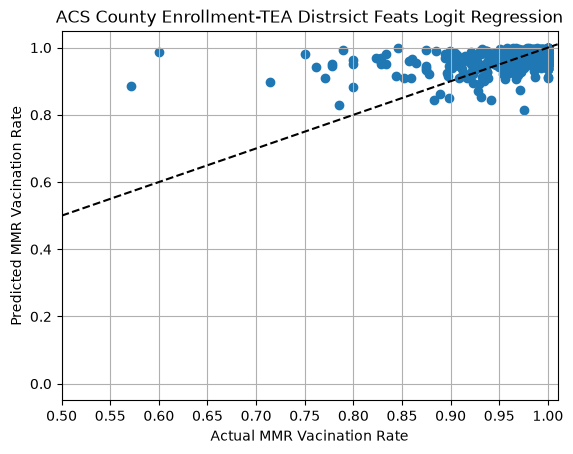

In [ ]:
#plot_vac_rates_predicted_actual(enroll_logit_vac_rates_dict, reg_type="Logit")
#plt.title("ACS County Enrollment-TEA Distrsict Feats Logit Regression")
#plt.ylim(75, 101)
#plt.yticks(custom_y_ticks_75_100)
#custom_x_ticks_p5_1 = np.arange(0.5, 1.05, 0.05)
#plt.xlim(0.5, 1.01)
#plt.xticks(custom_x_ticks_p5_1)

In [ ]:
#enroll_xgb_params = {'learning_rate': 0.088, 'n_estimators': 478,  'max_depth': 5, 'min_child_weight': 3, 'reg_lambda': 8}
#enroll_boost_regr_df, enroll_boost_regr_perform_dict, enroll_boost_regr_vac_rates_dict = ml_alogrithm_analysis(enroll_regr, model_type="Boost", drop_columns=tea_drop_columns, 
#                                                                                  hyper_params=enroll_xgb_params, algorithm_type="Regression")

MAE = 1.4311232024604075, RMSE = 4.358202574864788, R2 = 0.15612729254724012


In [ ]:
#enroll_xgb_params_r2 = {'n_estimators': 608, 'learning_rate': 0.1511, 'max_depth': 3, 'min_child_weight': 6, 'colsample_bytree': 0.8012,  'subsample': 0.7992, 'gamma': 0.4254, 'reg_alpha': 0.5201, 'reg_lambda': 0.8506}
#enroll_boost_regr_df_r2, enroll_boost_regr_perform_dict_r2, enroll_boost_regr_vac_rates_dict_r2 = ml_alogrithm_analysis(enroll_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
#                                                                                  hyper_params=enroll_xgb_params_r2, algorithm_type="Regression")

NameError: name 'enroll_regr_corr_reduced' is not defined

In [ ]:
#enroll_xgb_params_mae = {'n_estimators': 456, 'learning_rate': 0.1169, 'max_depth': 4, 'min_child_weight': 3, 'colsample_bytree': 0.6446,  'subsample': 0.9229, 'gamma': 0.3137, 'reg_alpha': 0.9244, 'reg_lambda': 3.1396}
#enroll_boost_regr_df_mae, enroll_boost_regr_perform_dict_mae, enroll_boost_regr_vac_rates_dict_mae = ml_alogrithm_analysis(enroll_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
#                                                                                  hyper_params=enroll_xgb_params_mae, algorithm_type="Regression")

In [ ]:
custom_y_ticks_75_100 = np.arange(75, 101, 2.5)
custom_y_ticks_60_100 = np.arange(60, 101, 2.5)
custom_x_ticks_0_100 = np.arange(0, 101, 5)
custom_x_ticks_5_100 = np.arange(5, 101, 5)

([<matplotlib.axis.XTick at 0x2b758c48610>,
 [Text(5, 0, '5'),
  Text(10, 0, '10'),
  Text(15, 0, '15'),
  Text(20, 0, '20'),
  Text(25, 0, '25'),
  Text(30, 0, '30'),
  Text(35, 0, '35'),
  Text(40, 0, '40'),
  Text(45, 0, '45'),
  Text(50, 0, '50'),
  Text(55, 0, '55'),
  Text(60, 0, '60'),
  Text(65, 0, '65'),
  Text(70, 0, '70'),
  Text(75, 0, '75'),
  Text(80, 0, '80'),
  Text(85, 0, '85'),
  Text(90, 0, '90'),
  Text(95, 0, '95'),
  Text(100, 0, '100')])

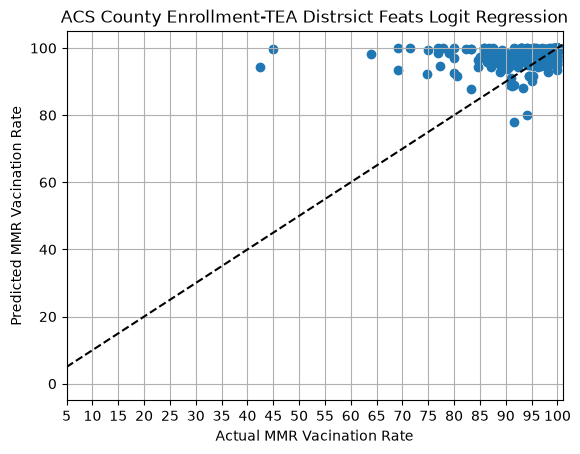

In [ ]:
#plot_vac_rates_predicted_actual(enroll_boost_regr_vac_rates_dict)
#plt.title("ACS County Enrollment-TEA Distrsict Feats Logit Regression")
#plt.xlim(5, 101)
#plt.xticks(custom_x_ticks_5_100)

Enrollment, TEA Staff Salary+Econ Disadvantaged

In [48]:
enroll_edu_sal_ridge_results_df, enroll_edu_sal_ridge_perf_dict, enroll_edu_sal_ridge_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_edu_sal_regr, 
                                                                                                           model_type='Ridge', drop_columns=tea_drop_columns)

R2 = 0.21873606129354972, MAE = 2.1817820872982514, RMSE = 4.300794587852962


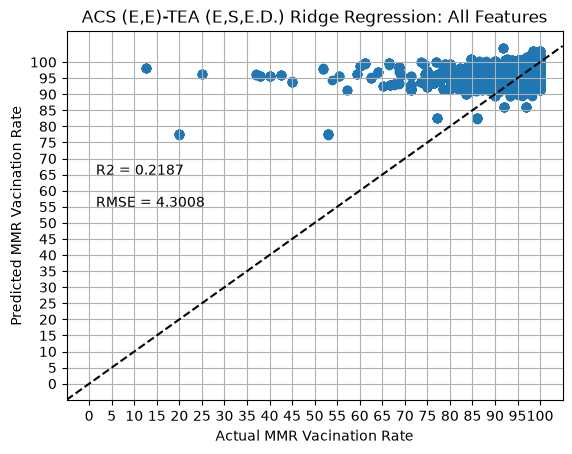

In [50]:
plot_vac_rates_predicted_actual(enroll_edu_sal_ridge_vac_rates_dict)
plt.title("ACS (E,E)-TEA (E,S,E.D.) Ridge Regression: All Features")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 65, f"R2 = {enroll_edu_sal_ridge_perf_dict['R2']:.4f}")
plt.text(1.5, 55, f"RMSE = {enroll_edu_sal_ridge_perf_dict['RMSE']:.4f}")
plt.savefig('../plots/traditional_regression/ridge_regression_vac_rates_acs_tea_full_features_actual_predict.png', bbox_inches="tight")

In [37]:
enroll_edu_sal_red_ridge_results_df, enroll_edu_sal_red_ridge_perf_dict, enroll_edu_sal_red_ridge_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_edu_sal_regr_corr_reduced, 
                                                                                                           model_type='Ridge', drop_columns=tea_drop_columns)

R2 = 0.2038688189408996, MAE = 2.207504712285875, RMSE = 4.341523218667214


Text(1.5, 55, 'RMSE = 4.3415')

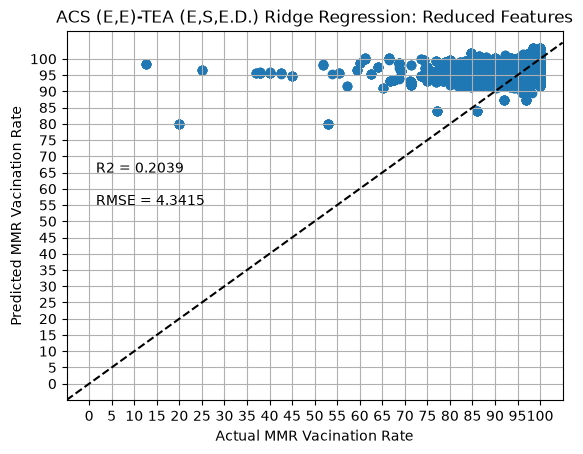

In [ ]:
plot_vac_rates_predicted_actual(enroll_edu_sal_red_ridge_vac_rates_dict)
plt.title("ACS (E,E)-TEA (E,S,E.D.) Ridge Regression: Reduced Features")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 65, f"R2 = {enroll_edu_sal_red_ridge_perf_dict['R2']:.4f}")
plt.text(1.5, 55, f"RMSE = {enroll_edu_sal_red_ridge_perf_dict['RMSE']:.4f}")
#plt.savefig('../plots/traditional_regression/ridge_regression_vac_rates_acs_tea_reduced_features_actual_predict.png', bbox_inches="tight")

In [ ]:
enroll_edu_sal_linear_results_df, enroll_edu_sal_linear_perf_dict, enroll_edu_sal_linear_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_edu_sal_regr, 
                                                                                                           model_type='Linear', drop_columns=tea_drop_columns)

KeyboardInterrupt: 

In [36]:
enroll_edu_sal_red_linear_results_df, enroll_edu_sal_red_linear_perf_dict, enroll_edu_sal_red_linear_vac_rates_dict = bootstrap_confidence_interval(1000, enroll_edu_sal_regr_corr_reduced, 
                                                                                                           model_type='Linear', drop_columns=tea_drop_columns)

R2 = 0.2038698878316827, MAE = 2.207535788107267, RMSE = 4.341520304187903


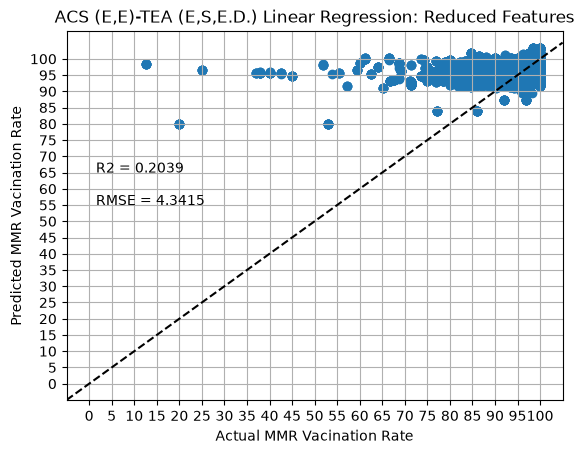

In [51]:
plot_vac_rates_predicted_actual(enroll_edu_sal_red_linear_vac_rates_dict)
plt.title("ACS (E,E)-TEA (E,S,E.D.) Linear Regression: Reduced Features")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 65, f"R2 = {enroll_edu_sal_red_linear_perf_dict['R2']:.4f}")
plt.text(1.5, 55, f"RMSE = {enroll_edu_sal_red_linear_perf_dict['RMSE']:.4f}")
plt.savefig('../plots/traditional_regression/linear_regression_vac_rates_acs_tea_reduced_features_actual_predict.png', bbox_inches="tight")

In [ ]:
enroll_edu_sal_logit_results_df, enroll_edu_sal_logit_perf_dict, enroll_edu_sal_logit_vac_rates_dict = bootstrap_confidence_interval(100, enroll_edu_sal_regr, 
                                                                                                           model_type='Logit', drop_columns=tea_drop_colu mns)

c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "
c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood o

         Current function value: 0.031097
         Iterations: 35


c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\statsmodels\base\model.py:607: ConvergenceWarning: Maximum Likelihood optimization failed to converge. Check mle_retvals
  warnings.warn("Maximum Likelihood optimization failed to "


R2 = 0.26227678388308795, MAE = 0.02061851221268871, RMSE = 0.040945653572347945


In [ ]:
enroll_edu_sal_xgb_params_r2_abs = {'n_estimators': 608, 'learning_rate': 0.1511, 'max_depth': 3, 'min_child_weight': 6, 'colsample_bytree': 0.8012,  'subsample': 0.7992, 'gamma': 0.4254, 'reg_alpha': 0.5201, 'reg_lambda': 0.8506}
enroll_edu_sal_boost_regr_df_r2_abs, enroll_edu_sal_boost_regr_perform_dict_r2_abs, enroll_edu_sal_boost_regr_vac_rates_dict_r2_abs = ml_alogrithm_analysis(enroll_edu_sal_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_r2_abs, algorithm_type="Regression", eval_obj="MAE")

MAE = 1.5200236566640375, RMSE = 4.122550840165049, R2 = 0.2821521267450434


In [6]:
enroll_edu_sal_xgb_params_mae = {'n_estimators': 456, 'learning_rate': 0.1169, 'max_depth': 4, 'min_child_weight': 3, 'colsample_bytree': 0.6446,  'subsample': 0.9229, 'gamma': 0.3137, 'reg_alpha': 0.9244, 'reg_lambda': 3.1396}
enroll_edu_sal_boost_regr_df_mae, enroll_edu_sal_boost_regr_perform_dict_mae, enroll_edu_sal_boost_regr_vac_rates_dict_mae = ml_alogrithm_analysis(enroll_edu_sal_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_mae, algorithm_type="Regression", eval_obj="MAE")

MAE = 1.3348329974092183, RMSE = 3.609609601864892, R2 = 0.4496729700826938


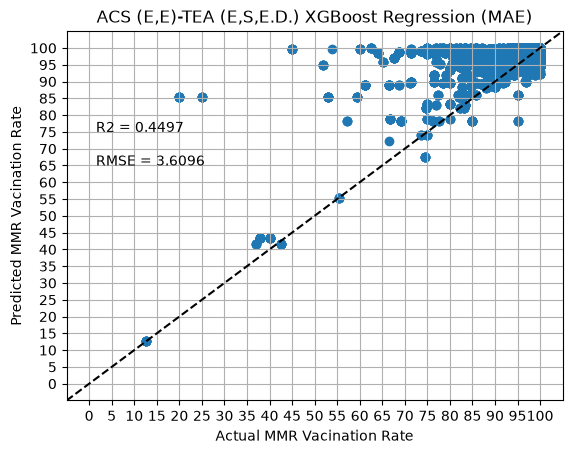

In [33]:
plot_vac_rates_predicted_actual(enroll_edu_sal_boost_regr_vac_rates_dict_mae)
plt.title("ACS (E,E)-TEA (E,S,E.D.) XGBoost Regression (MAE)")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 75, f"R2 = {enroll_edu_sal_boost_regr_perform_dict_mae['r2']:.4f}")
plt.text(1.5, 65, f"RMSE = {enroll_edu_sal_boost_regr_perform_dict_mae['RMSE']:.4f}")
plt.savefig('../plots/ML/xgb_regression_vac_rates_acs_tea_full_features_actual_predict_mae_focus.png', bbox_inches="tight")

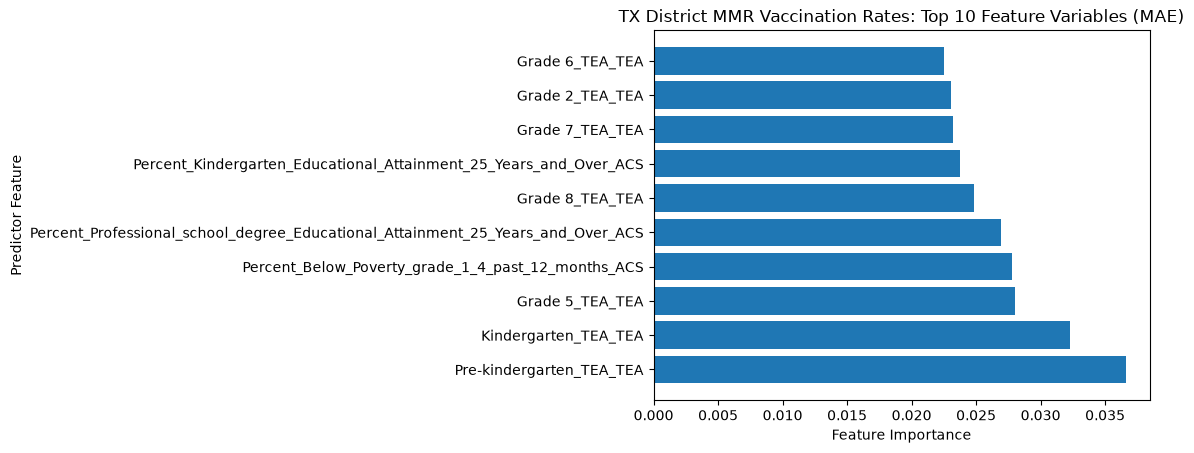

In [34]:
plt.barh(enroll_edu_sal_boost_regr_df_mae['Predictor'][:10], enroll_edu_sal_boost_regr_df_mae['Importance'][:10])
plt.ylabel("Predictor Feature")
plt.xlabel("Feature Importance")
plt.title("TX District MMR Vaccination Rates: Top 10 Feature Variables (MAE)")
plt.savefig('../plots/Features/xgb_regression_vac_rates_acs_tea_mae_focus_top_10.png', bbox_inches="tight")

In [ ]:
enroll_edu_sal_boost_regr_df_rmse, enroll_edu_sal_boost_regr_perform_dict_rmse, enroll_edu_sal_boost_regr_vac_rates_dict_rmse = ml_alogrithm_analysis(enroll_edu_sal_regr, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_mae, algorithm_type="Regression", eval_obj="RMSE")

MAE = 1.1384903707499587, RMSE = 2.482275596991784, R2 = 0.7397442261025348


In [38]:
enroll_edu_sal_xgb_params_rmse = {'n_estimators': 672, 'learning_rate': 0.0222, 'max_depth': 5, 'min_child_weight': 2, 'colsample_bytree': 0.7343,  'subsample': 0.7379, 'gamma': 0.1386, 'reg_alpha': 0.8719, 'reg_lambda': 6.5505}
enroll_edu_sal_boost_regr_df_rmse_opt, enroll_edu_sal_boost_regr_perform_dict_rmse_opt, enroll_edu_sal_boost_regr_vac_rates_dict_rmse_opt = ml_alogrithm_analysis(enroll_edu_sal_regr, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_rmse, algorithm_type="Regression", eval_obj="RMSE")

MAE = 1.231986867738246, RMSE = 2.5311451781512577, R2 = 0.7293958274441495


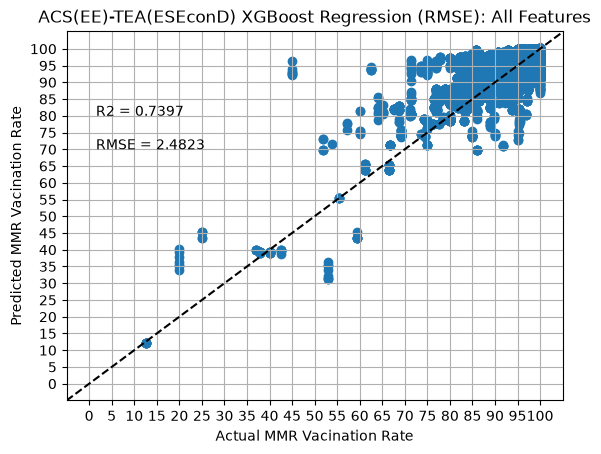

In [29]:
plot_vac_rates_predicted_actual(enroll_edu_sal_boost_regr_vac_rates_dict_rmse)
plt.title("ACS(EE)-TEA(ESEconD) XGBoost Regression (RMSE): All Features")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 80, f"R2 = {enroll_edu_sal_boost_regr_perform_dict_rmse['r2']:.4f}")
plt.text(1.5, 70, f"RMSE = {enroll_edu_sal_boost_regr_perform_dict_rmse['RMSE']:.4f}")
plt.savefig('../plots/ML/xgb_regression_vac_rates_acs_tea_full_features_actual_predict_rmse_focus.png', bbox_inches="tight")

In [16]:
enroll_edu_sal_boost_regr_df_rmse.head(10)

,Predictor,Importance
23,Percent_Middle_School_Hispanic_or_Latino_Alone...,0.107400
16,Percent_High_School_White_Alone_Not_Hispanic_o...,0.077397
80,Percent_3rd_grade_Educational_Attainment_25_Ye...,0.058996
8,Percent_School_Enrollment_White_Alone_Not_Hisp...,0.039949
28,Percent_Elementary_Two_or_More_Races_ACS,0.035831
61,Percent_grade_1_4_Private_ACS,0.028018
34,Percent_Above_Poverty_grade_1_4_past_12_months...,0.025663
105,Native Hawaiian/Other Pacific_TEA_TEA,0.023184
73,Percent_Private_ACS,0.020599
74,Percent_Public_ACS,0.016936


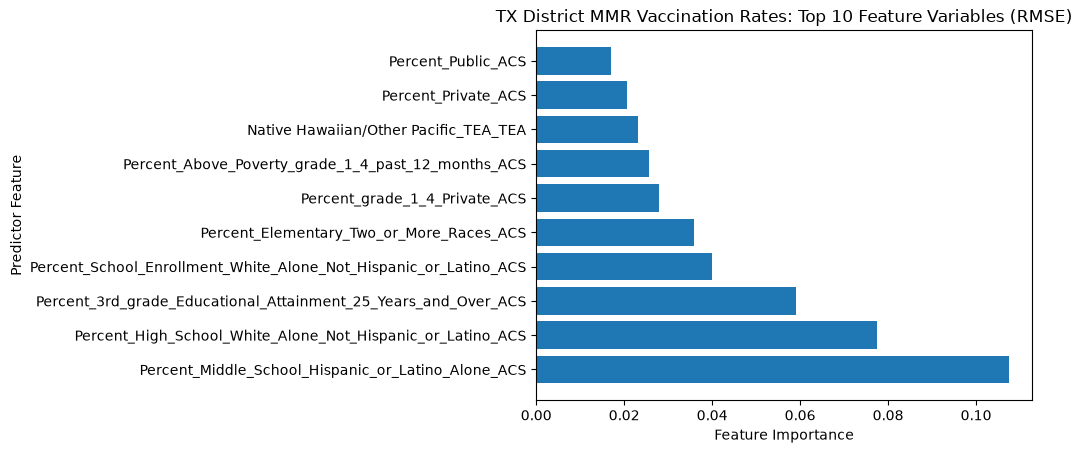

In [35]:
plt.barh(enroll_edu_sal_boost_regr_df_rmse['Predictor'][:10], enroll_edu_sal_boost_regr_df_rmse['Importance'][:10])
plt.ylabel("Predictor Feature")
plt.xlabel("Feature Importance")
plt.title("TX District MMR Vaccination Rates: Top 10 Feature Variables (RMSE)")
plt.savefig('../plots/Features/xgb_regression_vac_rates_acs_tea_rmse_focus_top_10.png', bbox_inches="tight")

In [ ]:

enroll_edu_sal_red_boost_regr_df_rmse, enroll_edu_sal_red_boost_regr_perform_dict_rmse, enroll_edu_sal_red_boost_regr_vac_rates_dict_rmse = ml_alogrithm_analysis(enroll_edu_sal_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_mae, algorithm_type="Regression", eval_obj="RMSE")

MAE = 1.1407642693578615, RMSE = 2.4824311034214492, R2 = 0.7397116167388127


In [39]:
enroll_edu_sal_red_boost_regr_df_rmse_opt, enroll_edu_sal_red_boost_regr_perform_dict_rmse_opt, enroll_edu_sal_red_boost_regr_vac_rates_dict_rmse_opt = ml_alogrithm_analysis(enroll_edu_sal_regr_corr_reduced, model_type="Boost", drop_columns=tea_drop_columns, 
                                                                                  hyper_params=enroll_edu_sal_xgb_params_rmse, algorithm_type="Regression", eval_obj="RMSE")

MAE = 1.2440956293207517, RMSE = 2.543349500682032, R2 = 0.7267800134692937


Text(1.5, 70, 'RMSE = 2.4824')

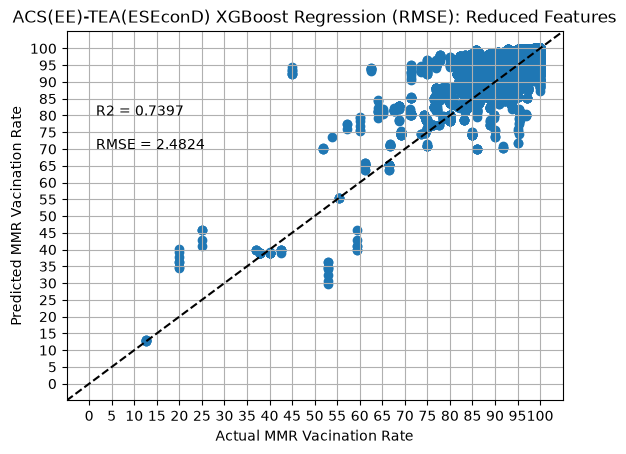

In [22]:
plot_vac_rates_predicted_actual(enroll_edu_sal_red_boost_regr_vac_rates_dict_rmse)
plt.title("ACS(EE)-TEA(ESEconD) XGBoost Regression (RMSE): Reduced Features")
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)
plt.text(1.5, 80, f"R2 = {enroll_edu_sal_red_boost_regr_perform_dict_rmse['r2']:.4f}")
plt.text(1.5, 70, f"RMSE = {enroll_edu_sal_red_boost_regr_perform_dict_rmse['RMSE']:.4f}")

([<matplotlib.axis.YTick at 0x2b1e08a3050>,
 [Text(0, 0, '0'),
  Text(0, 5, '5'),
  Text(0, 10, '10'),
  Text(0, 15, '15'),
  Text(0, 20, '20'),
  Text(0, 25, '25'),
  Text(0, 30, '30'),
  Text(0, 35, '35'),
  Text(0, 40, '40'),
  Text(0, 45, '45'),
  Text(0, 50, '50'),
  Text(0, 55, '55'),
  Text(0, 60, '60'),
  Text(0, 65, '65'),
  Text(0, 70, '70'),
  Text(0, 75, '75'),
  Text(0, 80, '80'),
  Text(0, 85, '85'),
  Text(0, 90, '90'),
  Text(0, 95, '95'),
  Text(0, 100, '100')])

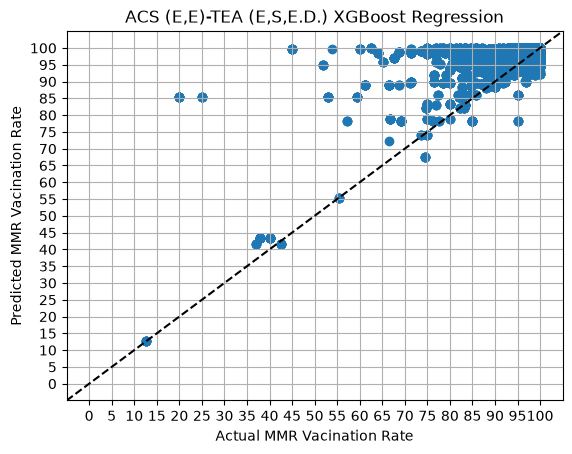

In [ ]:
plot_vac_rates_predicted_actual(enroll_edu_sal_boost_regr_vac_rates_dict_mae)
plt.title("ACS (E,E)-TEA (E,S,E.D.) XGBoost Regression")
xg_xtick = np.arange(0, 101, 5)
xg_ytick = np.arange(0, 101, 5)
plt.xticks(xg_xtick)
plt.yticks(xg_ytick)

c:\Users\19037\Documents\Measels_Vaccination\envMeasVac\Lib\site-packages\IPython\core\pylabtools.py:170: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  fig.canvas.print_figure(bytes_io, **kw)


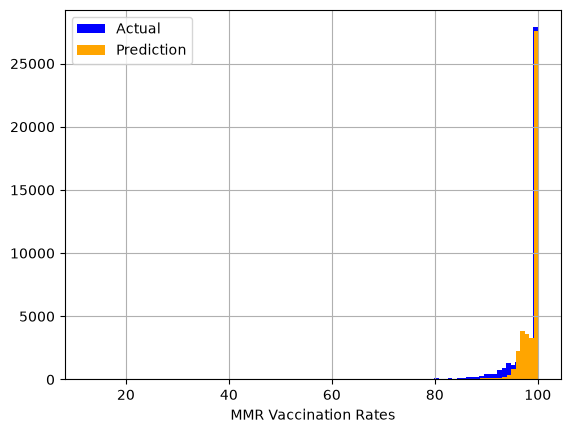

In [ ]:
make_predicted_actual_histo(enroll_edu_sal_boost_regr_vac_rates_dict_mae, num_test_bins=100, num_predict_bins=100)